# Análisis EDA y Clasificación de Tickets de Incidentes Bancarios

Este notebook realiza un análisis exploratorio de datos (EDA) y un modelo de clasificación para predecir la categoría de cada ticket de incidentes bancarios a partir de un archivo CSV.

## 1. Carga de Librerías y Configuración Inicial

In [40]:
# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize':(10,6)})

## 2. Carga y Exploración Inicial de Datos

In [83]:
# Cargar el archivo CSV
# Usa la ruta absoluta o relativa correcta según tu entorno
ruta_csv = 'Categorizaciones_incidentes_depurado.csv'  # Archivo está en la misma carpeta que el notebook
import os
print('Directorio actual:', os.getcwd())
print('Archivos en el directorio actual:', os.listdir())
print('Archivos en ./Data:', os.listdir('./') if os.path.exists('./') else 'No existe ./')

# Intenta cargar el archivo
try:
    df = pd.read_csv(ruta_csv, sep=',', encoding='latin-1')
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()

Directorio actual: c:\Users\paomaribel\Documents\GitHub\Asignador\Data
Archivos en el directorio actual: ['Categorizaciones incidentes_depurado (2).xlsx', 'Categorizaciones incidentes_depurado.xlsx', 'Categorizaciones_incidentes_clasificadas.csv', 'Categorizaciones_incidentes_depurado(Hoja1).csv', 'Categorizaciones_incidentes_depurado.csv', 'EDA_Categorizacion_Incidentes.ipynb']
Archivos en ./Data: ['Categorizaciones incidentes_depurado (2).xlsx', 'Categorizaciones incidentes_depurado.xlsx', 'Categorizaciones_incidentes_clasificadas.csv', 'Categorizaciones_incidentes_depurado(Hoja1).csv', 'Categorizaciones_incidentes_depurado.csv', 'EDA_Categorizacion_Incidentes.ipynb']
Dimensiones: (7353, 30)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Categoría
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,NANCY CECILIA NASIMBA CHALCO,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Activos
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Activos
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Activos
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Activos
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LEONELA JACKELINE DELGADO MENDIETA,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   number                      7353 non-null   str  
 1   state                       7353 non-null   str  
 2   sys_created_on              7353 non-null   str  
 3   category                    7353 non-null   str  
 4   u_subcategory               7353 non-null   str  
 5   u_subcategory_2             7353 non-null   str  
 6   contact_type                7353 non-null   str  
 7   business_duration           7353 non-null   int64
 8   cmdb_ci_business_app        4793 non-null   str  
 9   cmdb_ci                     2329 non-null   str  
 10  short_description           7353 non-null   str  
 11  priority                    7353 non-null   str  
 12  severity                    7353 non-null   str  
 13  caller_id                   7353 non-null   str  
 14  u_affected_user    

cmdb_ci                       5024
cmdb_ci_business_app          2560
comments_and_work_notes       1453
u_subcategoria_error           641
u_categoria_error              639
location.cmn_location_type     587
location                       587
Categoría                      331
u_affected_user.department     116
resolved_at                     27
close_notes                     26
assigned_to                      7
description                      5
u_affected_user                  3
u_affected_user.title            3
dtype: int64

In [86]:
# Exploración rápida de variables informativas
print('Resumen de columnas:')
df.info()
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)

Resumen de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   number                      7353 non-null   str  
 1   state                       7353 non-null   str  
 2   sys_created_on              7353 non-null   str  
 3   category                    7353 non-null   str  
 4   u_subcategory               7353 non-null   str  
 5   u_subcategory_2             7353 non-null   str  
 6   contact_type                7353 non-null   str  
 7   business_duration           7353 non-null   int64
 8   cmdb_ci_business_app        4793 non-null   str  
 9   cmdb_ci                     2329 non-null   str  
 10  short_description           7353 non-null   str  
 11  priority                    7353 non-null   str  
 12  severity                    7353 non-null   str  
 13  caller_id                   7353 non-null   str  
 14

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [87]:
# Mostrar las primeras filas del archivo CSV para conocer la estructura
display(df.head())

,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Categoría
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,NANCY CECILIA NASIMBA CHALCO,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Activos
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Activos
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Activos
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Activos
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LEONELA JACKELINE DELGADO MENDIETA,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
# Cambiar el nombre de la columna 'Categoria' por 'Clasificación'
df = df.rename(columns={"Categoría": "Clasificación"})

In [91]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[               'Activos',                      nan,      'Estados de cuenta',
       'Formas numeradas',                      '0',              'Chequeras',
                'Cheques',                 'SISREP',              'BancsLink',
                'Cajeros',            'Inversiones',           'Contabilidad',
              'Pendiente',                'Cuentas',              'No aplica',
          'No productivo',              'Garantías',                    'ATS',
            'Incidencias',               'Clientes',      'Estados de Cuenta',
       'Formas Numeradas',     'Firmas Autorizadas',                  'Bancs',
         'Reportes Batch',        'Reportes Online', 'Retenciones Judiciales',
               'Cuentas ',               'Créditos',     'Firmas autorizadas',
             'Sobregiros',       'Notas de crédito',                'Cartola',
                 'Riesgo',                  'Giros',           'Pago directo',
     

In [92]:
# Normalización de valores en la columna 'Clasificación'
import unicodedata
import re

def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    # unicodedata elimina tildes → los replace manuales son innecesarios pero no dañan
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)   
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())

<StringArray>
[               'activos',         'sin_clasificar',      'estados de cuenta',
       'formas numeradas',                      '0',              'chequeras',
                'cheques',                 'sisrep',              'bancslink',
                'cajeros',            'inversiones',           'contabilidad',
              'pendiente',                'cuentas',              'no aplica',
          'no productivo',              'garantias',                    'ats',
            'incidencias',               'clientes',     'firmas autorizadas',
                  'bancs',         'reportes batch',        'reportes online',
 'retenciones judiciales',               'creditos',             'sobregiros',
       'notas de credito',                'cartola',                 'riesgo',
                  'giros',           'pago directo',                   'cnbs',
               'procesos',                  'mt940',               'usuarios',
            'tricklefeed',   'certific

In [93]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [94]:
# Reemplazar '0', nan y 'no aplica' por 'sin_clasificar'
df['Clasificación'] = df['Clasificación'].replace(['0', 0, None, np.nan, 'no aplica'], 'sin_clasificar')

In [95]:
# 3. Asignar 'mt940' a 'forma numerada'
df['Clasificación'] = df['Clasificación'].replace('mt940', 'forma numerada')

In [96]:
# Mostrar valores únicos tras la limpieza y agrupación en orden alfabético y de forma vertical
for valor in sorted(df['Clasificación'].unique()):
    print(valor)

activo
ats
bancs
bancslink
cajeros
cartola
cc-evento-alerta
certificado bancario
cheque
chequeras
cliente
cnbs
co-titular
contabilidad
creditos
cuenta
estados de cuenta
firmas autorizadas
forma numerada
garantia
giros
incidencias
inversion
no productivo
notas de credito
pago directo
pendiente
proceso
reporte batch
reporte online
retenciones judiciales
riesgo
sin_clasificar
sisrep
sobregiro
tricklefeed
usuario


In [97]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
sin_clasificar            3769
bancslink                  707
activo                     531
cuenta                     448
pendiente                  370
inversion                  366
contabilidad               211
forma numerada             183
chequeras                  152
cheque                     150
sisrep                     132
estados de cuenta           60
cliente                     59
garantia                    44
retenciones judiciales      39
firmas autorizadas          38
no productivo               35
reporte batch                9
bancs                        7
riesgo                       6
ats                          5
cnbs                         5
cc-evento-alerta             4
incidencias                  3
reporte online               3
giros                        3
proceso                      3
certificado bancario         2
cajeros                      1
creditos                     1
sobregiro                    1
notas de credito         

In [98]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 0
No se encontraron filas duplicadas.


## 4. Análisis Exploratorio de Datos (EDA)


--- severity ---


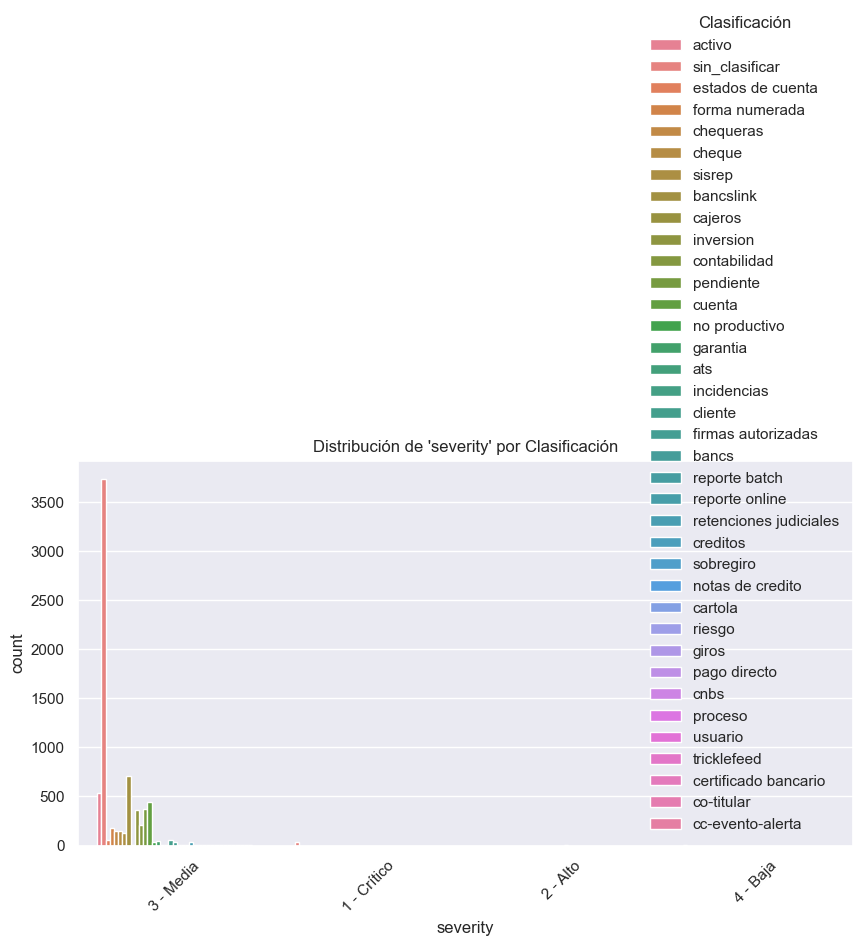

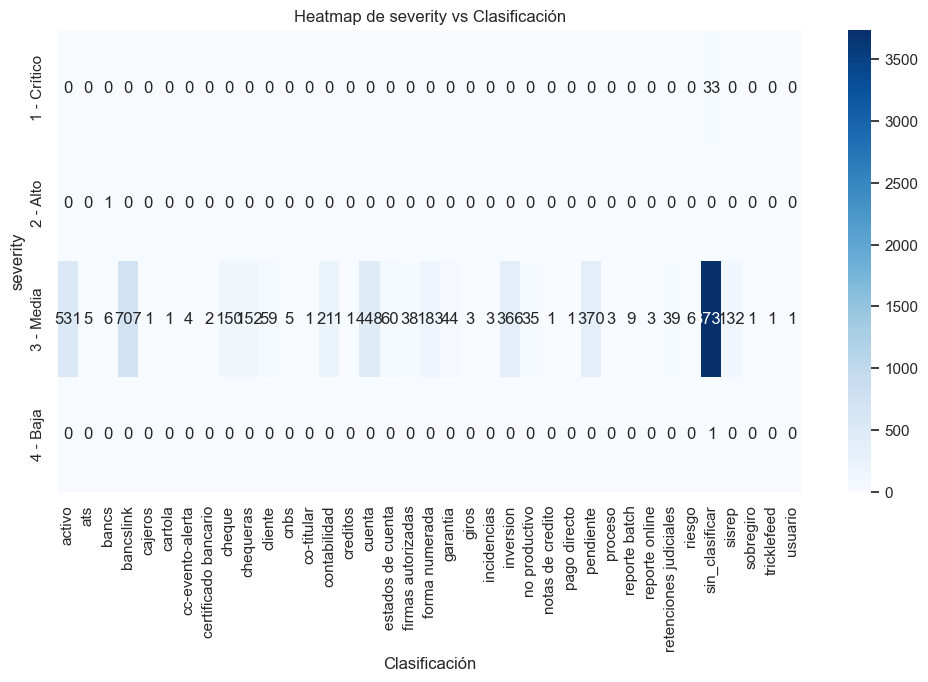


--- contact_type ---


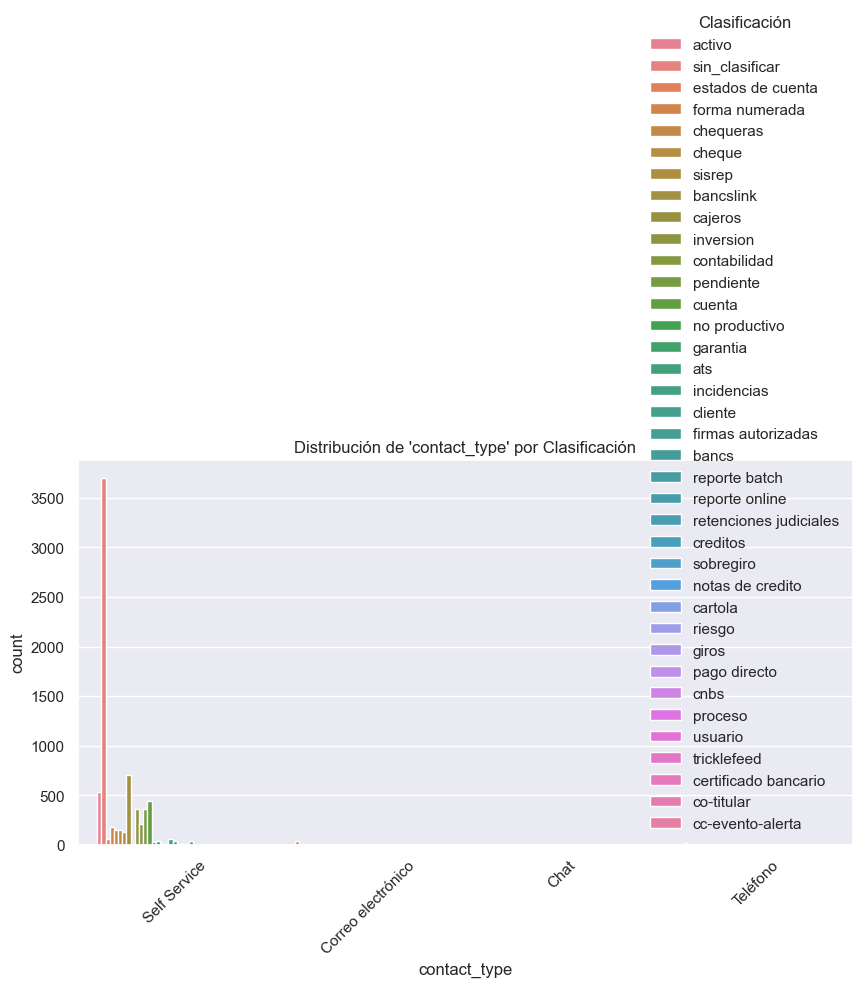

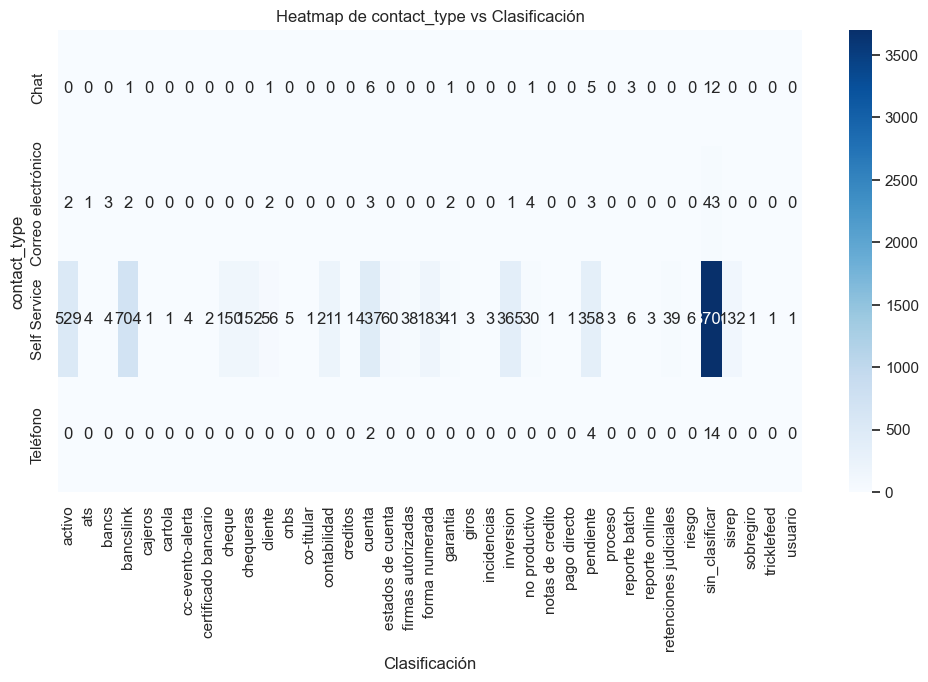


--- assignment_group ---


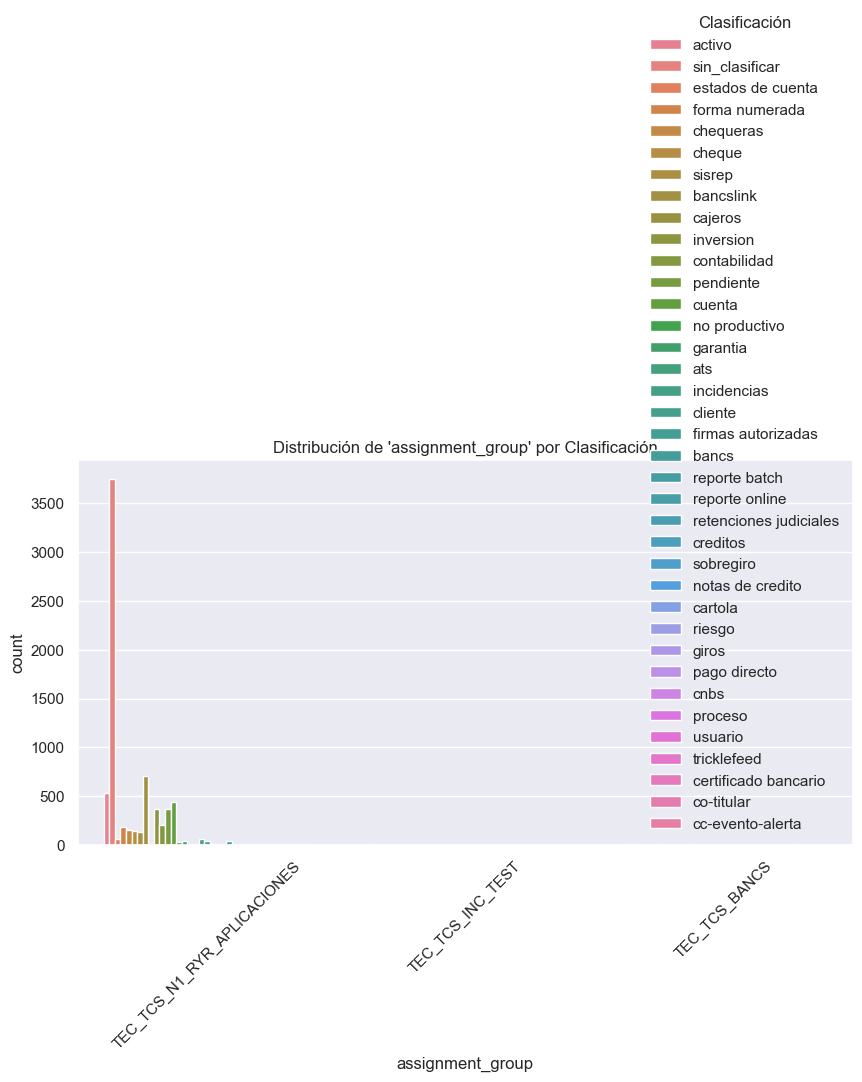

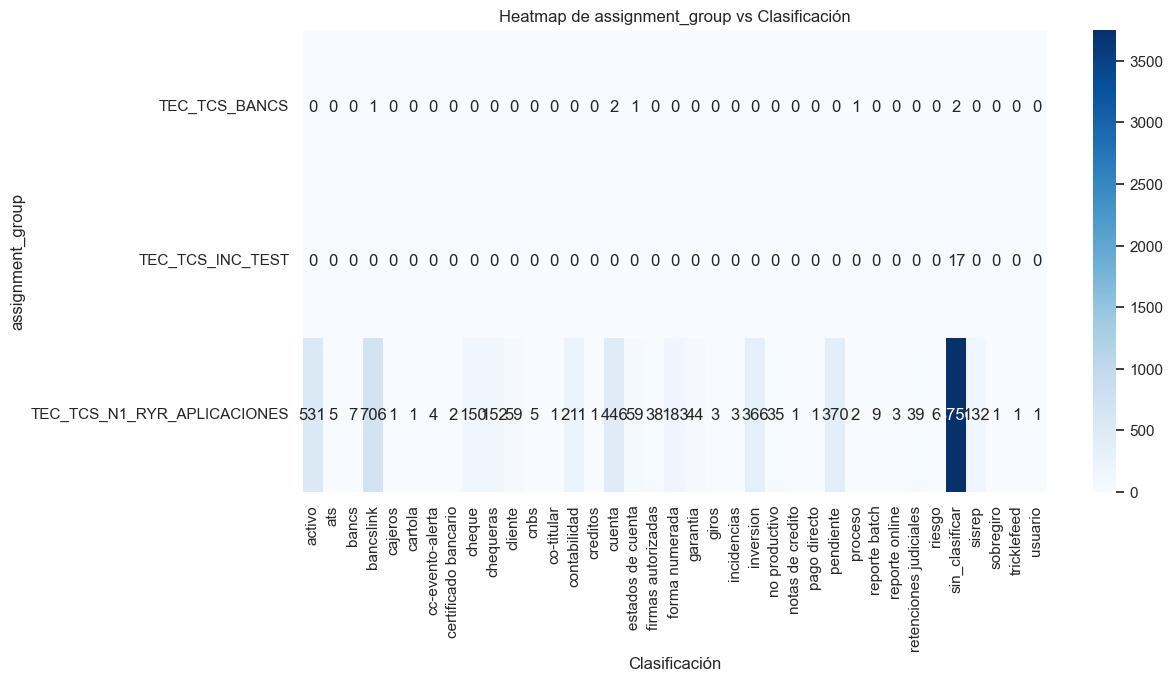


--- u_subcategory ---


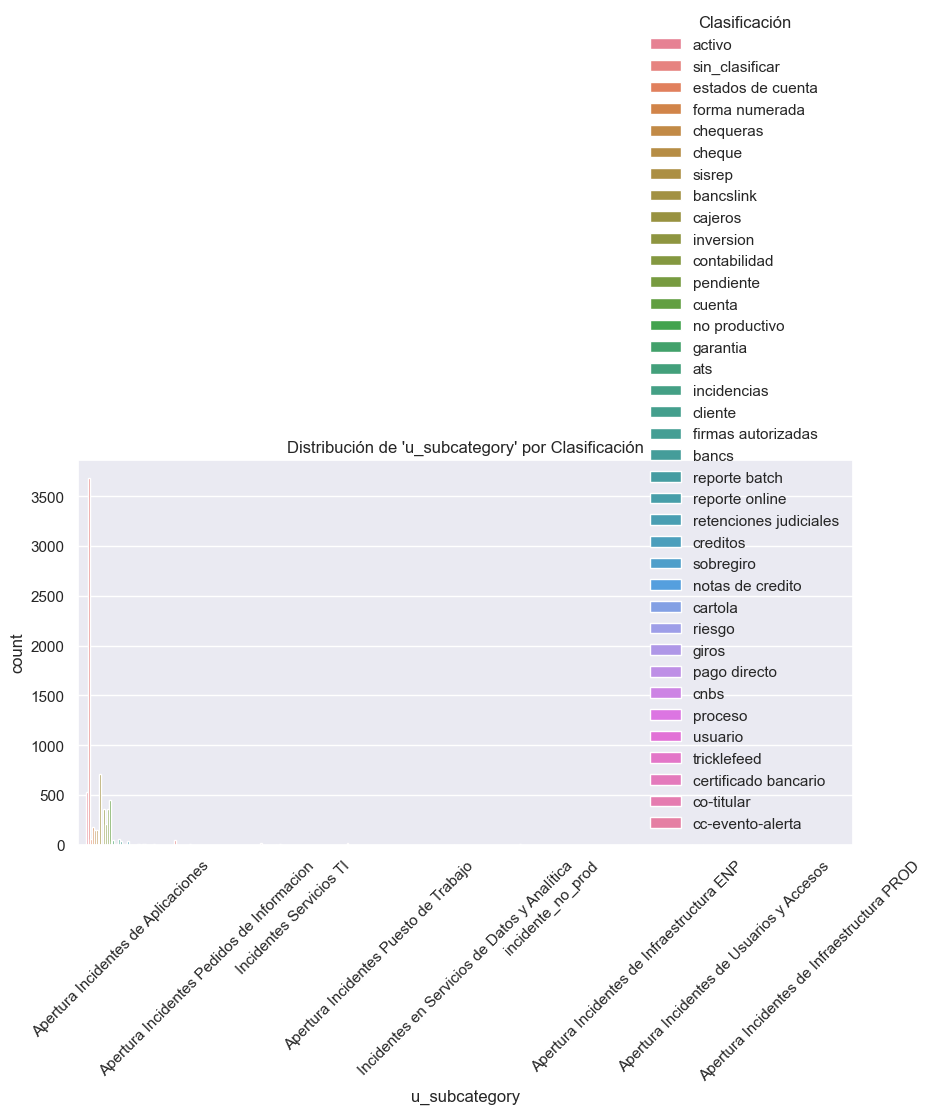

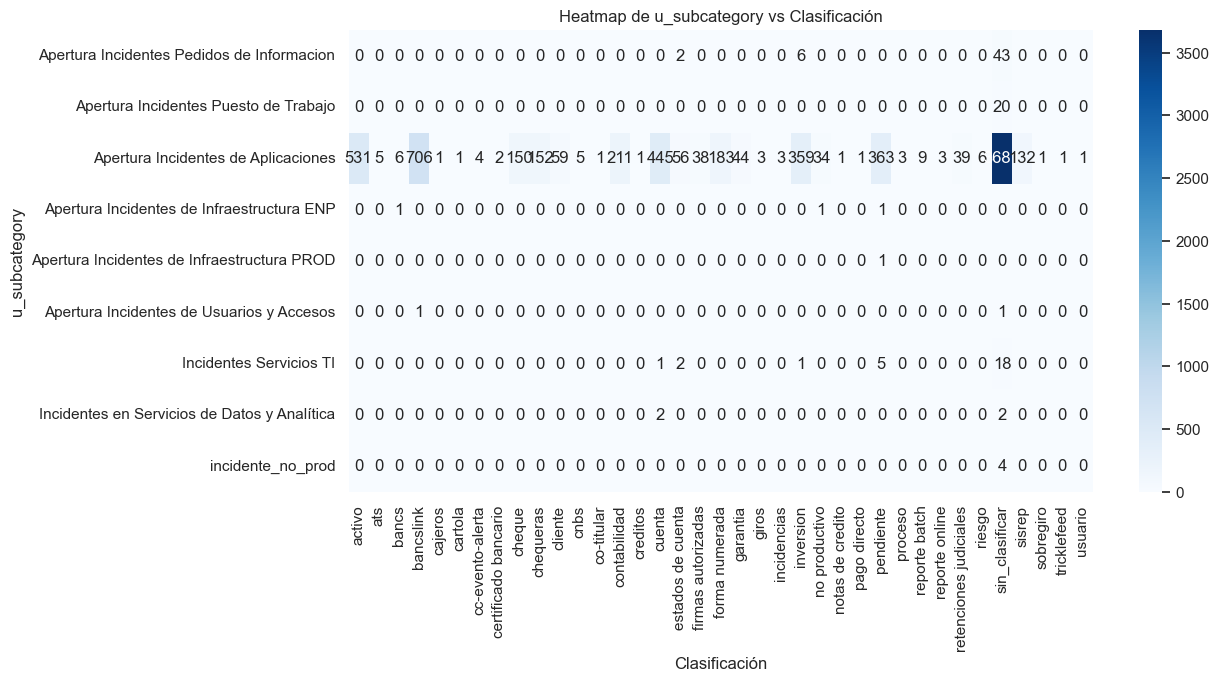


--- u_subcategory_2 ---


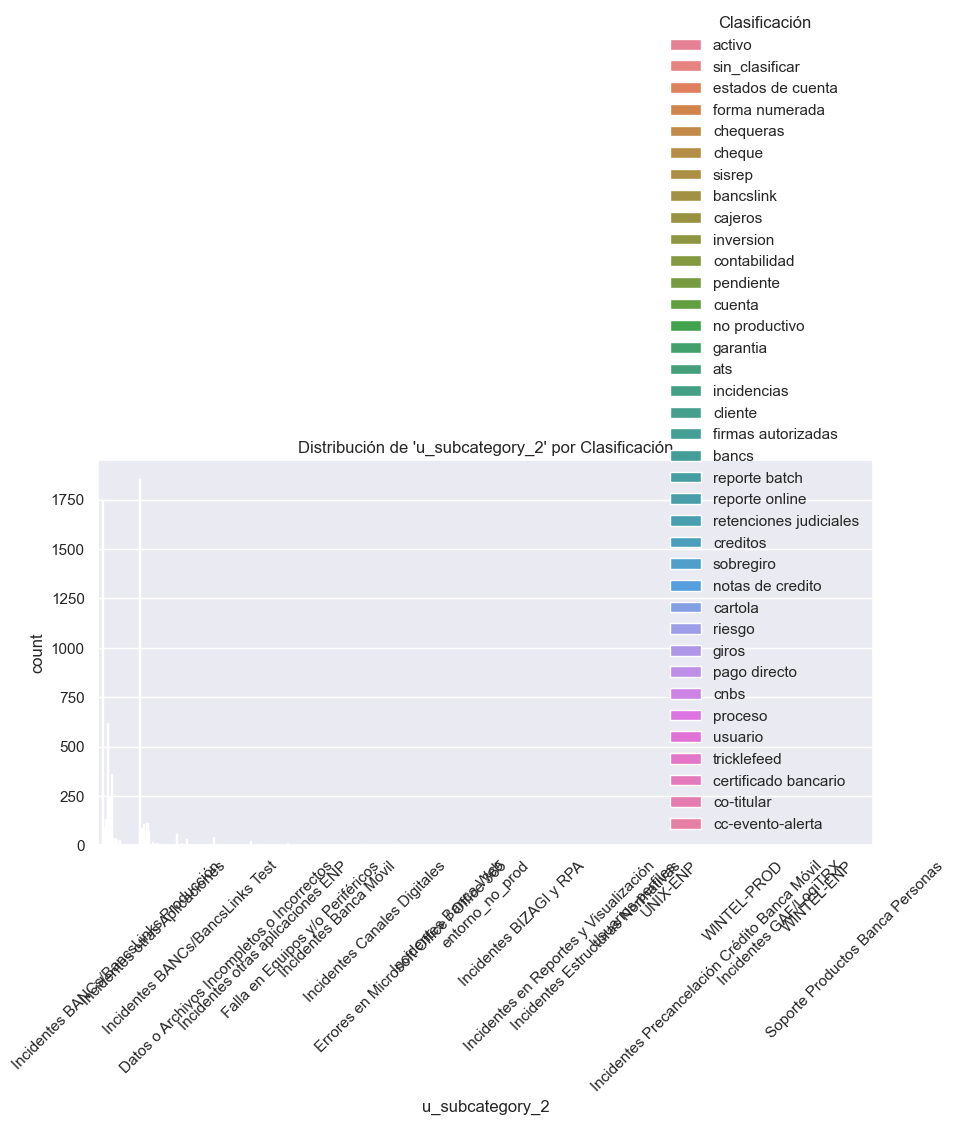

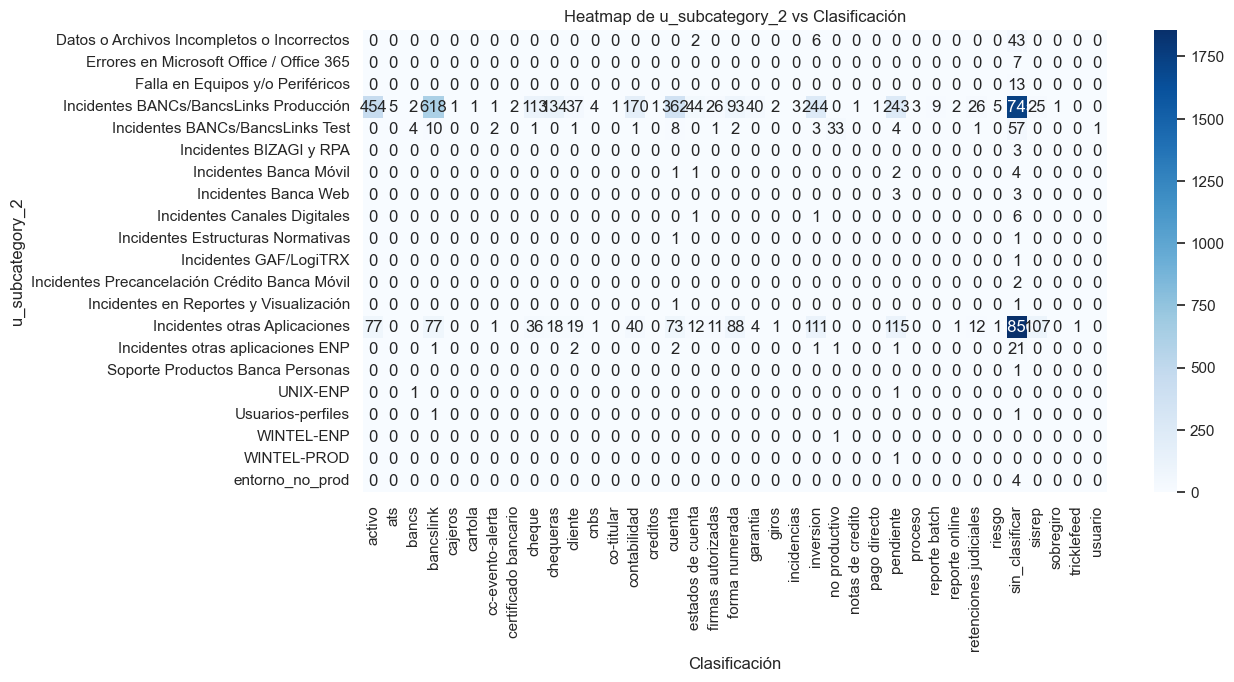

In [20]:
# Gráficos de barras apiladas y heatmaps para columnas categóricas relevantes
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

columnas_categoricas = [
    'priority', 'severity', 'contact_type', 'assignment_group', 'Origen', 'Ambiente',
    'u_subcategory', 'u_subcategory_2'
]

for col in columnas_categoricas:
    if col in df.columns and df[col].nunique() > 1 and df[col].nunique() < 25:
        print(f"\n--- {col} ---")
        # Gráfico de barras apiladas
        plt.figure(figsize=(10,5))
        sns.countplot(data=df, x=col, hue='Clasificación', order=df[col].value_counts().index)
        plt.title(f"Distribución de '{col}' por Clasificación")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Heatmap de la tabla de contingencia
        tabla = pd.crosstab(df[col], df['Clasificación'])
        plt.figure(figsize=(12,6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de {col} vs Clasificación")
        plt.show()

In [22]:
# 2. Variables numéricas vs. Clasificación (ANOVA y boxplots)
num_vars = [col for col in columnas_informativas if df[col].dtype in ['int64', 'float64']]
for col in num_vars:
    print(f"\nBoxplot y ANOVA: {col} vs Clasificación")
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x='Clasificación', y=col)
    plt.title(f"Distribución de '{col}' por Clasificación")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # ANOVA solo si hay más de un grupo
    grupos = [g[1] for g in df.groupby('Clasificación')[col] if len(g[1]) > 1]
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"p-valor ANOVA: {p:.4f}")

KeyError: 'Categoría'

## 5. Preparación de Datos para Modelado

In [99]:
# Unificar texto relevante para análisis de similitud
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['u_subcategory'].fillna('') + ' ' +
    df['u_subcategory_2'].fillna('')
)

In [100]:
df['texto_unificado'] 

0       segun ticket RITM0800991  sugiere ingresar el ...
1       CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...
2       Favor su apoyo, revisando el abono al capital,...
3       repago invalido  por favor su ayuda con la reg...
4       su gentil ayuda con el siguiente caso la clien...
                              ...                        
7348    ERROR BANCS ERROR al ingresar a bancs del usua...
7349    Error en bank links Error en banksnlink  en lo...
7350    error de cobro cliente 0605206614 Estimados, f...
7351    Seguir el flujo de la INC0020554 Su ayuda con ...
7352    cancelación  de cuanta y el documento para cie...
Name: texto_unificado, Length: 7353, dtype: str

In [101]:
def limpiar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)   # ✓ BUG CORREGIDO: era r'[^a-zA-Z0-9\\s]'
    texto = re.sub(r'\s+', ' ', texto).strip()        # ✓ BUG CORREGIDO: era r'\\s+'
    return texto

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)
df['texto_unificado']

0       segun ticket ritm0800991 sugiere ingresar el r...
1       con fecha 22 de enero 2026 las operaciones 800...
2       favor su apoyo revisando el abono al capital e...
3       repago invalido por favor su ayuda con la regu...
4       su gentil ayuda con el siguiente caso la clien...
                              ...                        
7348    error bancs error al ingresar a bancs del usua...
7349    error en bank links error en banksnlink en los...
7350    error de cobro cliente 0605206614 estimados fa...
7351    seguir el flujo de la inc0020554 su ayuda con ...
7352    cancelacion de cuanta y el documento para cier...
Name: texto_unificado, Length: 7353, dtype: str

In [102]:
# Separar tickets clasificados y no clasificados
df_clasificados = df[df['Clasificación'] != 'sin_clasificar'].copy()
df_no_clasificados = df[df['Clasificación'] == 'sin_clasificar'].copy()
print(f"Tickets clasificados: {df_clasificados.shape[0]}")
print(f"Tickets sin clasificar: {df_no_clasificados.shape[0]}")

Tickets clasificados: 3584
Tickets sin clasificar: 3769


In [103]:
# Importar nltk y descargar stopwords en español
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
spanish_stopwords = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\paomaribel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Vectorización 

In [104]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
import joblib

# ===== PASO 1: VECTORIZACIÓN ÚNICA Y CONSISTENTE =====
# Crear UNA SOLA instancia del vectorizer que usaremos en todo el pipeline
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words=spanish_stopwords)

# Vectorizar datos clasificados
X_clasificados = vectorizer.fit_transform(df_clasificados['texto_unificado'])
y_clasificados = df_clasificados['Clasificación'].values

# Vectorizar datos sin clasificar (usando el MISMO vectorizer)
X_no_clasificados = vectorizer.transform(df_no_clasificados['texto_unificado'])

print("Distribución original de clases:", Counter(y_clasificados))
print(f"Matriz X_clasificados shape: {X_clasificados.shape}")
print(f"Vectorizer features: {vectorizer.get_feature_names_out().shape[0]}")

Distribución original de clases: Counter({'bancslink': 707, 'activo': 531, 'cuenta': 448, 'pendiente': 370, 'inversion': 366, 'contabilidad': 211, 'forma numerada': 183, 'chequeras': 152, 'cheque': 150, 'sisrep': 132, 'estados de cuenta': 60, 'cliente': 59, 'garantia': 44, 'retenciones judiciales': 39, 'firmas autorizadas': 38, 'no productivo': 35, 'reporte batch': 9, 'bancs': 7, 'riesgo': 6, 'ats': 5, 'cnbs': 5, 'cc-evento-alerta': 4, 'incidencias': 3, 'reporte online': 3, 'giros': 3, 'proceso': 3, 'certificado bancario': 2, 'cajeros': 1, 'creditos': 1, 'sobregiro': 1, 'notas de credito': 1, 'cartola': 1, 'pago directo': 1, 'usuario': 1, 'tricklefeed': 1, 'co-titular': 1})
Matriz X_clasificados shape: (3584, 3000)
Vectorizer features: 3000


## Balanceo de clases

In [105]:
from scipy.sparse import vstack
from imblearn.over_sampling import SMOTE, RandomOverSampler

# ===== PASO 2: SPLIT ESTRATIFICADO (SIEMPRE ANTES de oversampling/SMOTE) =====
# Razón: SMOTE genera puntos sintéticos interpolando muestras reales.
# Si se hace antes del split, muestras derivadas de datos reales pueden caer
# en el test set → el modelo "conoce" datos similares al test → data leakage.

# Identificar clases con menos de 2 ejemplos (no estratificables)
conteo_clases_y = pd.Series(y_clasificados).value_counts()
clases_pocas = conteo_clases_y[conteo_clases_y < 2].index.tolist()

if clases_pocas:
    print(f"  Clases con solo 1 ejemplo (van directo a train): {clases_pocas}")
    mask_pocas = pd.Series(y_clasificados).isin(clases_pocas).values
    X_pocas, y_pocas = X_clasificados[mask_pocas], y_clasificados[mask_pocas]
    X_suf, y_suf = X_clasificados[~mask_pocas], y_clasificados[~mask_pocas]

    X_train_main, X_test, y_train_main, y_test = train_test_split(
        X_suf, y_suf, test_size=0.2, random_state=42, stratify=y_suf
    )
    X_train = vstack([X_train_main, X_pocas])
    y_train = np.concatenate([y_train_main, y_pocas])
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_clasificados, y_clasificados, test_size=0.2, random_state=42, stratify=y_clasificados
    )

print(f"\n✓ Train set: {X_train.shape[0]} muestras")
print(f"✓ Test set:  {X_test.shape[0]} muestras (intacto, nunca modificado)")

# ===== PASO 3: SMOTE SOLO EN TRAIN =====
# SMOTE necesita al menos k_neighbors+1 muestras por clase.
# Calculamos k_neighbors seguro según la clase menos representada en train.
conteo_train = Counter(y_train)
min_class_count = min(conteo_train.values())
k_neighbors = min(5, min_class_count - 1)

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"\n✓ Balanceo con SMOTE (k_neighbors={k_neighbors})")
    print("  SMOTE genera muestras SINTÉTICAS interpolando entre vecinos reales.")
else:
    # Fallback: alguna clase tiene solo 1 muestra → SMOTE no puede interpolar
    ros = RandomOverSampler(random_state=42)
    X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)
    print("\n  Fallback a RandomOverSampler (clase con solo 1 muestra en train)")

print(f"\nDistribución en TRAIN antes del balanceo: {len(conteo_train)} clases")
print(f"Distribución en TRAIN después del balanceo:")
print(Counter(y_train_balanced))

  Clases con solo 1 ejemplo (van directo a train): ['cajeros', 'creditos', 'sobregiro', 'notas de credito', 'cartola', 'pago directo', 'usuario', 'tricklefeed', 'co-titular']

✓ Train set: 2869 muestras
✓ Test set:  715 muestras (intacto, nunca modificado)

  Fallback a RandomOverSampler (clase con solo 1 muestra en train)

Distribución en TRAIN antes del balanceo: 36 clases
Distribución en TRAIN después del balanceo:
Counter({'inversion': 566, 'reporte batch': 566, 'activo': 566, 'bancslink': 566, 'contabilidad': 566, 'sisrep': 566, 'cuenta': 566, 'forma numerada': 566, 'giros': 566, 'cheque': 566, 'chequeras': 566, 'pendiente': 566, 'estados de cuenta': 566, 'cnbs': 566, 'no productivo': 566, 'firmas autorizadas': 566, 'retenciones judiciales': 566, 'reporte online': 566, 'cliente': 566, 'garantia': 566, 'bancs': 566, 'certificado bancario': 566, 'ats': 566, 'riesgo': 566, 'cc-evento-alerta': 566, 'incidencias': 566, 'proceso': 566, 'cajeros': 566, 'creditos': 566, 'sobregiro': 566, 

## KNN

### Método del codo

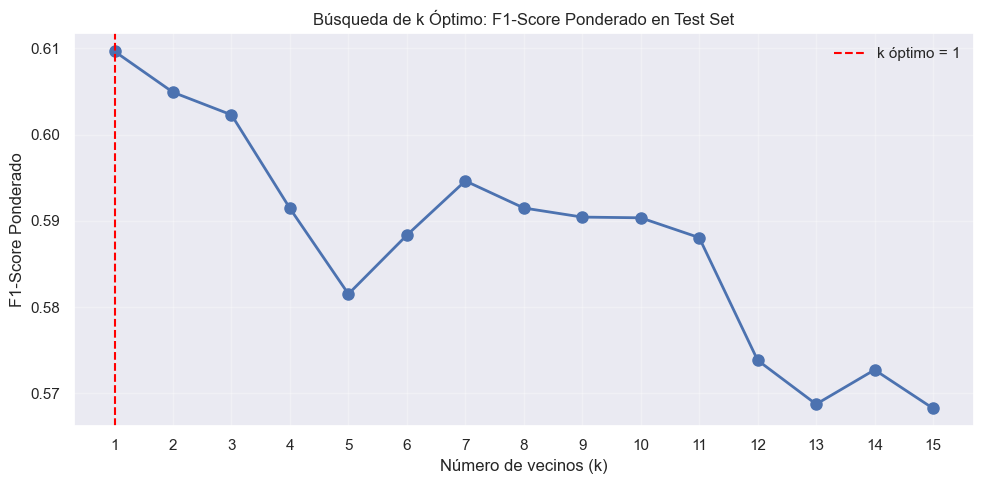


✓ k óptimo encontrado: 1
  F1-Score en test set: 0.6097


In [107]:
# ===== PASO 4: BÚSQUEDA DE k ÓPTIMO (SIN data leakage) =====
# Método del codo mejorado: usa TRAIN y TEST que ya hemos separado
# Y SOLO ENTRENA EN TRAIN BALANCEADO

from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

k_range = range(1, 16)
f1_scores = []  # Usar F1-score en lugar de accuracy

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    # Entrena SOLO en train balanceado (sin ver test)
    knn.fit(X_train_balanced, y_train_balanced)
    # Evalúa en test (datos nuevos)
    y_pred = knn.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_scores.append(f1)

# Encontrar k óptimo
k_optimo_idx = np.argmax(f1_scores)
k_optimo = list(k_range)[k_optimo_idx]

plt.figure(figsize=(10, 5))
plt.plot(k_range, f1_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.title('Búsqueda de k Óptimo: F1-Score Ponderado en Test Set')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('F1-Score Ponderado')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ k óptimo encontrado: {k_optimo}")
print(f"  F1-Score en test set: {max(f1_scores):.4f}")

In [108]:
# ===== PASO 5: ENTRENAMIENTO FINAL CON k ÓPTIMO =====
# Entrenar SOLO con datos balanceados de TRAIN
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_train_balanced, y_train_balanced)

print(f"✓ Modelo KNN entrenado con k={k_optimo}")
print(f"  Datos de entrenamiento: {X_train_balanced.shape[0]} muestras")

# Clasificar los tickets no clasificados
y_pred_no_clasificados = knn_final.predict(X_no_clasificados)
df_no_clasificados['Clasificación_predicha'] = y_pred_no_clasificados

print(f"\n✓ Clasificados {df_no_clasificados.shape[0]} tickets sin clasificar")
print('\nEjemplos de tickets no clasificados y su predicción:')
display(df_no_clasificados[['texto_unificado', 'Clasificación_predicha']].head(10))

✓ Modelo KNN entrenado con k=1
  Datos de entrenamiento: 20376 muestras

✓ Clasificados 3769 tickets sin clasificar

Ejemplos de tickets no clasificados y su predicción:


,texto_unificado,Clasificación_predicha
4,su gentil ayuda con el siguiente caso la clien...,chequeras
5,error estado de cuenta historico plataforma no...,sisrep
7,validacion de pago de credito estimados por fa...,activo
9,no coinciden valores por pago de credito su ay...,activo
10,la cliente maria sol salinas representante de ...,cuenta
11,regresar a estado 1 en cheque devuelto en apli...,cuenta
12,revision procesador contable bancs satelite mu...,bancslink
13,error dos inversiones sin devolucion total est...,inversion
14,diferencia entre saldo contable y el disponibl...,cuenta
15,error cuenta salta como inactiva en el portal ...,cuenta


In [109]:
# ===== PASO 6: EVALUACIÓN EN TEST SET (sin data leakage) =====
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Predecir en TEST SET (datos que el modelo NUNCA vio)
y_pred_test = knn_final.predict(X_test)

# Calcular métricas robustas
accuracy = accuracy_score(y_test, y_pred_test)
precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET (Datos nuevos - SIN data leakage)")
print("="*60)
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (ponderado): {precision_weighted:.4f}")
print(f"Recall (ponderado):    {recall_weighted:.4f}")
print(f"F1-Score (ponderado):  {f1_weighted:.4f}")

print("="*60)
print("REPORTE DE CLASIFICACIÓN (Por clase):")
print(classification_report(y_test, y_pred_test, zero_division=0))


EVALUACIÓN EN TEST SET (Datos nuevos - SIN data leakage)
Accuracy:              0.6126
Precision (ponderado): 0.6144
Recall (ponderado):    0.6126
F1-Score (ponderado):  0.6097
REPORTE DE CLASIFICACIÓN (Por clase):
                        precision    recall  f1-score   support

                activo       0.74      0.84      0.78       106
                   ats       0.00      0.00      0.00         1
                 bancs       0.00      0.00      0.00         1
             bancslink       0.64      0.70      0.66       141
      cc-evento-alerta       0.00      0.00      0.00         1
  certificado bancario       0.00      0.00      0.00         0
                cheque       0.43      0.50      0.46        30
             chequeras       0.67      0.67      0.67        30
               cliente       0.19      0.25      0.21        12
                  cnbs       0.33      1.00      0.50         1
          contabilidad       0.92      0.81      0.86        42
               

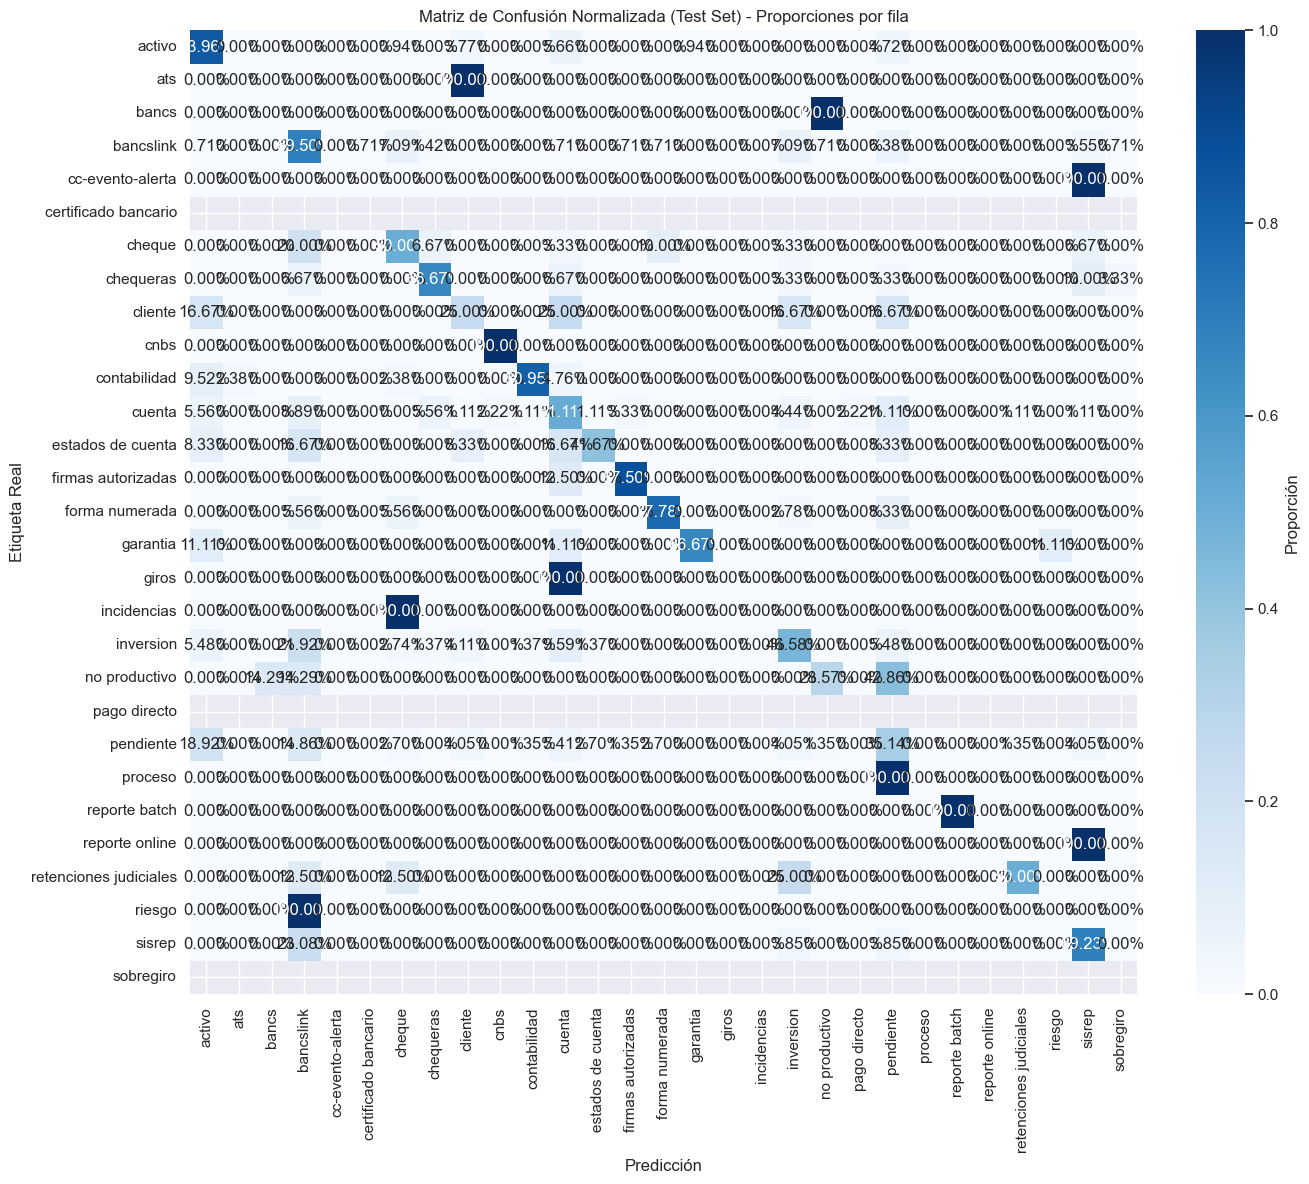

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar matriz de confusión normalizada
labels = sorted(list(set(list(y_test) + list(y_pred_test))))
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proporción'})
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Normalizada (Test Set) - Proporciones por fila')
plt.tight_layout()
plt.show()

## Comparativa de Clasificadores

=== Métricas comparativas (conjunto de prueba) ===

                     Accuracy  F1-Score  Precision  Recall
Modelo                                                    
KNN                    0.6126    0.6097     0.6144  0.6126
LinearSVC              0.7119    0.7017     0.7061  0.7119
Logistic Regression    0.7259    0.7204     0.7259  0.7259


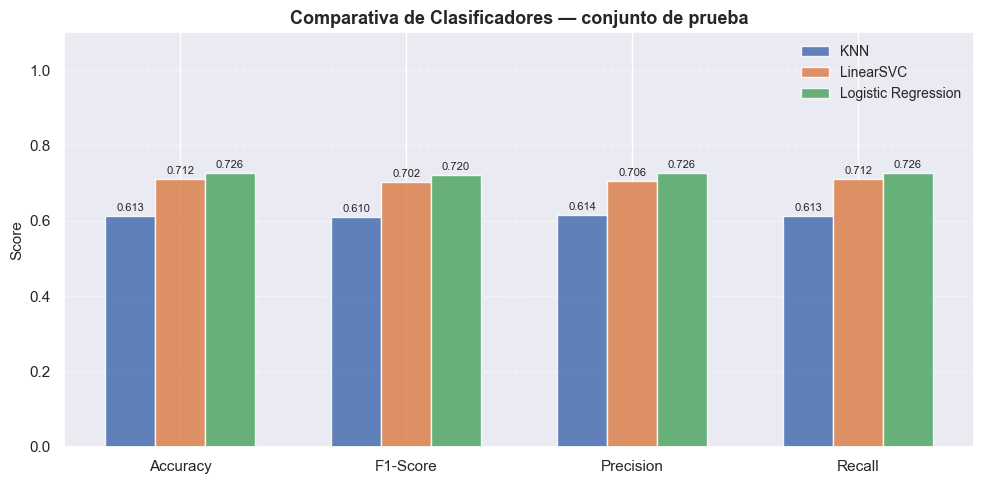


► Mejor clasificador por F1-Score (weighted): Logistic Regression  (0.7204)


In [115]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# ── Definición de clasificadores ─────────────────────────────────────────────
modelos = {
    'KNN': knn_final,
    'LinearSVC': LinearSVC(max_iter=3000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=1.0, solver='lbfgs')
}

# ── Entrenamiento (solo los nuevos), evaluación y guardado de predicciones ────
resultados = []
predicciones_modelos = {}
for nombre, modelo in modelos.items():
    if nombre != 'KNN':
        modelo.fit(X_train_balanced, y_train_balanced)
    y_pred_m = modelo.predict(X_test)
    predicciones_modelos[nombre] = y_pred_m
    resultados.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, y_pred_m),
        'F1-Score':  f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Precision': precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred_m, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# ── Tabla de métricas ─────────────────────────────────────────────────────────
print("=== Métricas comparativas (conjunto de prueba) ===\n")
print(df_resultados.round(4).to_string())

# ── Gráfico de barras comparativo ─────────────────────────────────────────────
metricas = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metricas))
ancho = 0.22
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.88)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparativa de Clasificadores — conjunto de prueba', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Mejor modelo ──────────────────────────────────────────────────────────────
mejor = df_resultados['F1-Score'].idxmax()
print(f"\n► Mejor clasificador por F1-Score (weighted): {mejor}  "
      f"({df_resultados.loc[mejor, 'F1-Score']:.4f})")

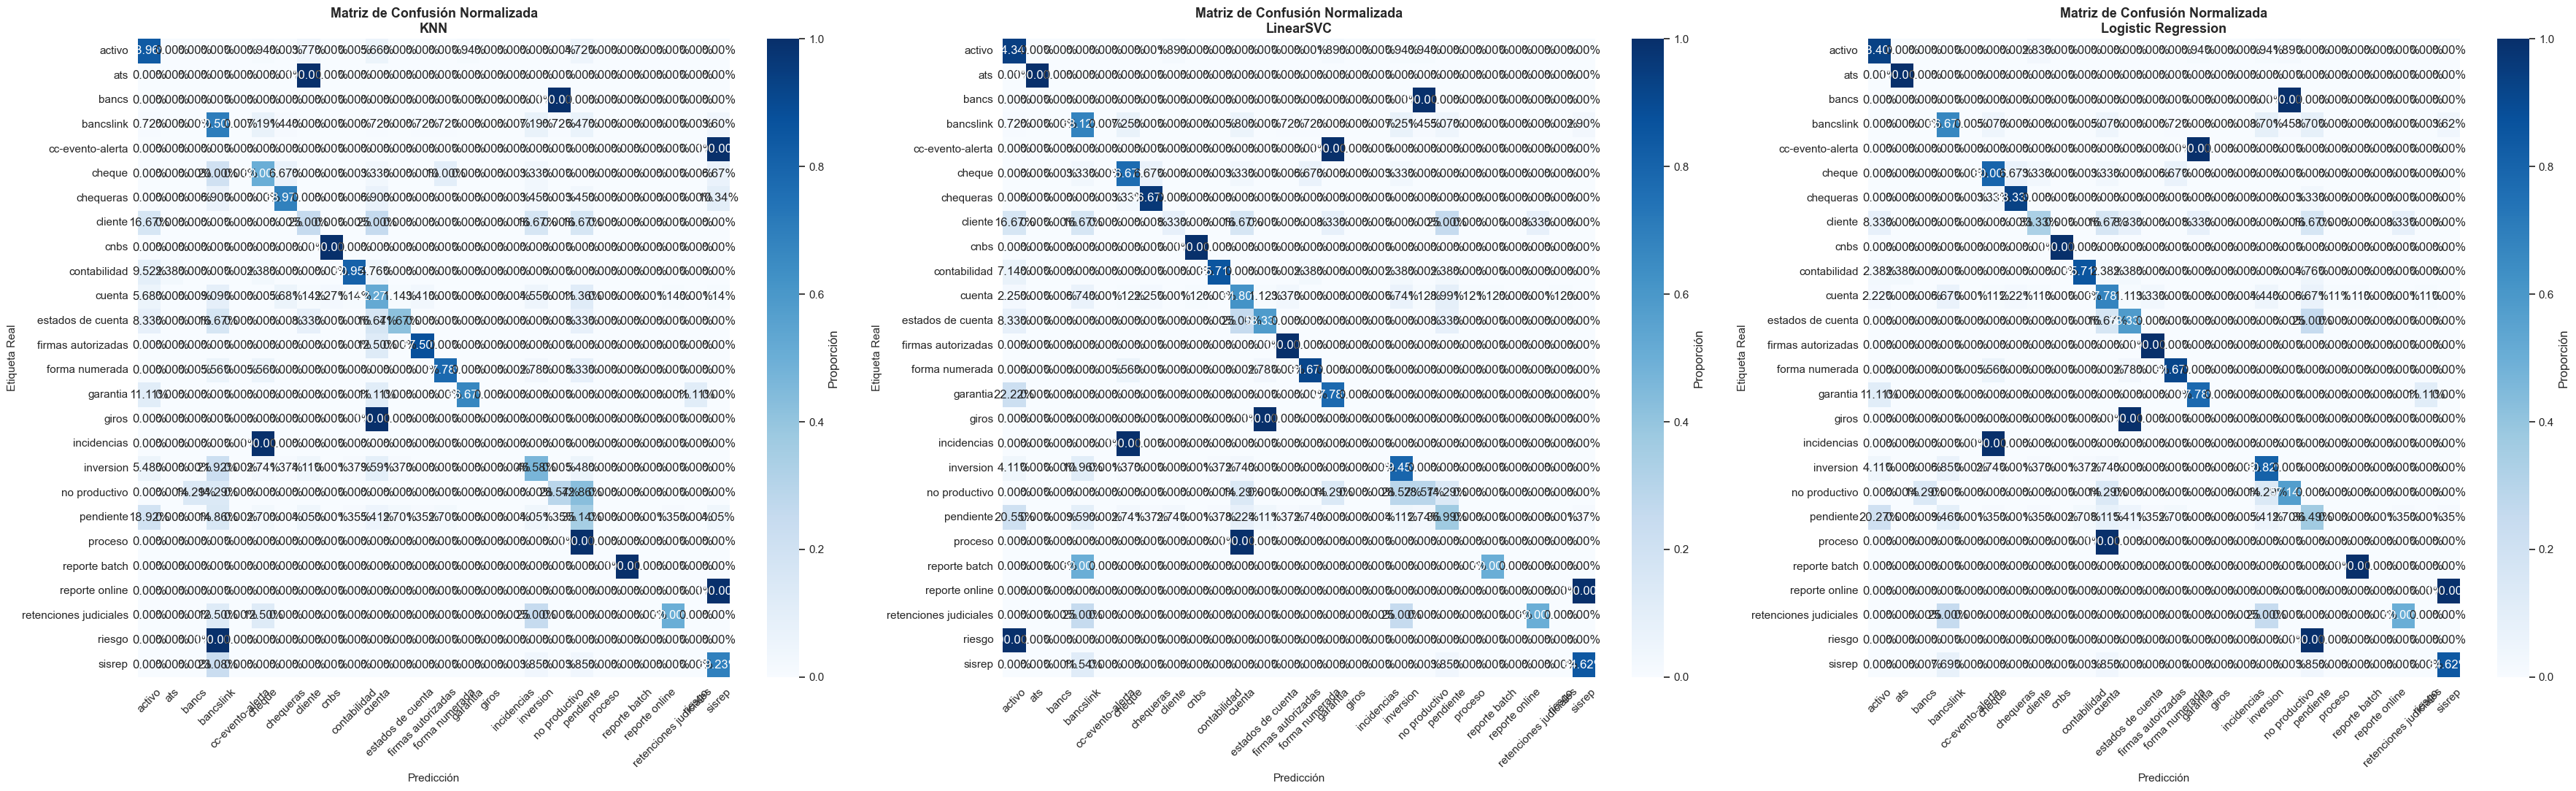

In [116]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(list(set(list(y_test))))

fig, axes = plt.subplots(1, 3, figsize=(36, 11))

for ax, (nombre, y_pred_m) in zip(axes, predicciones_modelos.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Proporción'}, ax=ax
    )
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_title(f'Matriz de Confusión Normalizada\n{nombre}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()